# TRABAJO SERIES TEMPORALES

In [708]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import ARIMA
import math
from pmdarima import auto_arima

               Sales
Month               
2001-01-01  1359.795
2001-02-01  1278.564
2001-03-01  1508.327
2001-04-01  1419.710
2001-05-01  1440.510


(array([10957., 11688., 12418., 13149., 13879., 14610., 15340., 16071.]),
 [Text(10957.0, 0, '2000'),
  Text(11688.0, 0, '2002'),
  Text(12418.0, 0, '2004'),
  Text(13149.0, 0, '2006'),
  Text(13879.0, 0, '2008'),
  Text(14610.0, 0, '2010'),
  Text(15340.0, 0, '2012'),
  Text(16071.0, 0, '2014')])

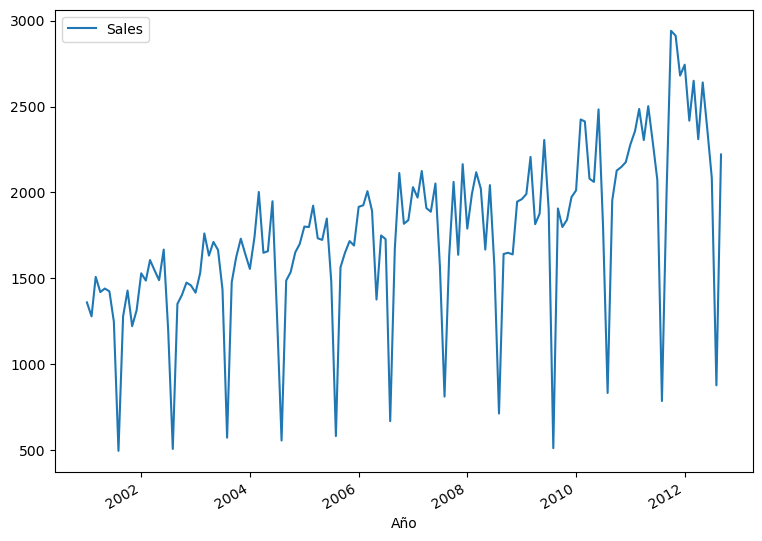

In [ ]:


papers = pd.read_excel(r"papers.xlsx")
papers['Month'] = papers['Month'].apply(lambda x: f"200{x}" if int(x.split('-')[0]) < 10 else f"20{x}")
papers['Month'] = pd.to_datetime(papers['Month'], format='%Y-%m')

papers = papers.sort_values(by='Month', ascending=True).reset_index(drop=True) 
papers.index = papers['Month']
del papers['Month']
print(papers.head())

plt.figure(figsize=(9,6))
sns.lineplot(papers, color='blue')
plt.legend()
plt.xlabel('Año')
plt.xticks(rotation=30, ha='right')

Se puede observar como la varianza es ligeramente creciente y la media no es del todo constante. No será pues estacionaria. Hay ligera tendencia positiva y una estacionalidad clara

# esquema multiplicativo o aditivo?

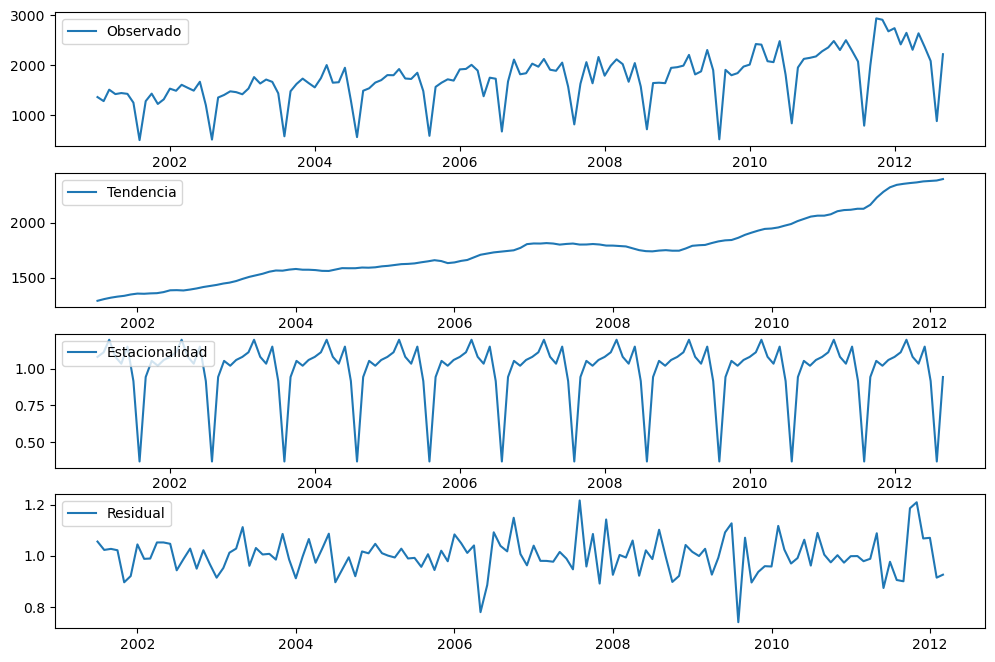

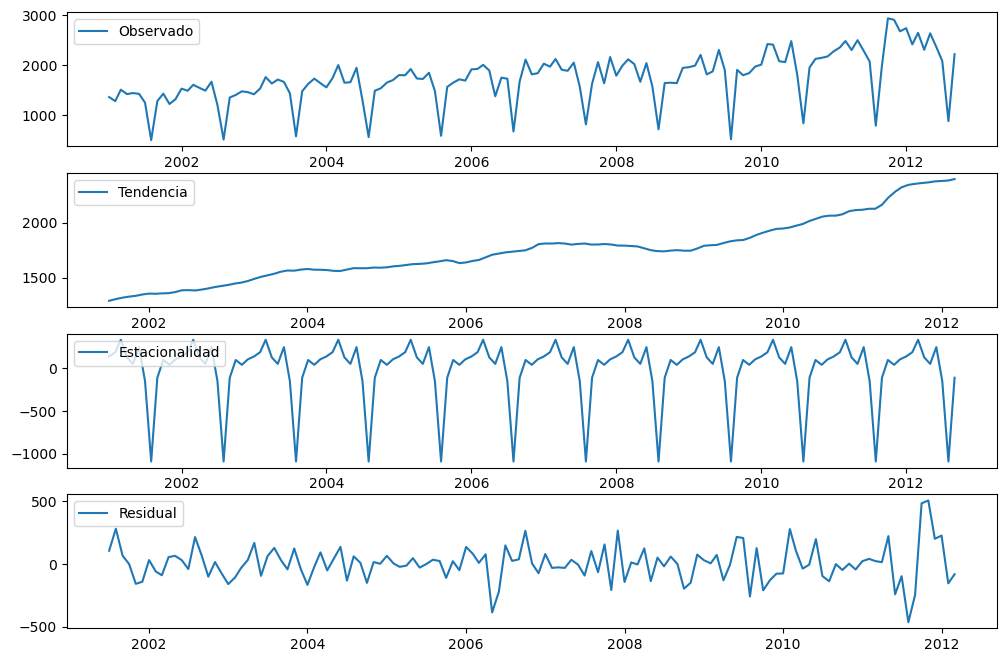

In [710]:
result_papers_mul = seasonal_decompose(papers['Sales'], model='multiplicative')


plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(result_papers_mul.observed, label='Observado')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(result_papers_mul.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
#result.seasonal nos dara las componentes de estacionalidad
plt.plot(result_papers_mul.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(result_papers_mul.resid, label='Residual')
plt.legend(loc='upper left')


#result_papers_mul.plot()


result_papers_add = seasonal_decompose(papers['Sales'], model='additive')


plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(result_papers_add.observed, label='Observado')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(result_papers_add.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
#result.seasonal nos dara las componentes de estacionalidad
plt.plot(result_papers_add.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(result_papers_add.resid, label='Residual')
plt.legend(loc='upper left')


#result_papers_add.plot()


In [711]:
result_papers_mul.seasonal

Month
2001-01-01    1.078608
2001-02-01    1.109965
2001-03-01    1.194734
2001-04-01    1.079242
2001-05-01    1.032727
                ...   
2012-05-01    1.032727
2012-06-01    1.148323
2012-07-01    0.914930
2012-08-01    0.370438
2012-09-01    0.942547
Name: seasonal, Length: 141, dtype: float64

In [712]:
result_papers_add.seasonal

Month
2001-01-01     140.781291
2001-02-01     190.740181
2001-03-01     337.083636
2001-04-01     129.752861
2001-05-01      53.560882
                 ...     
2012-05-01      53.560882
2012-06-01     250.465840
2012-07-01    -149.717845
2012-08-01   -1092.748792
2012-09-01    -108.655270
Name: seasonal, Length: 141, dtype: float64

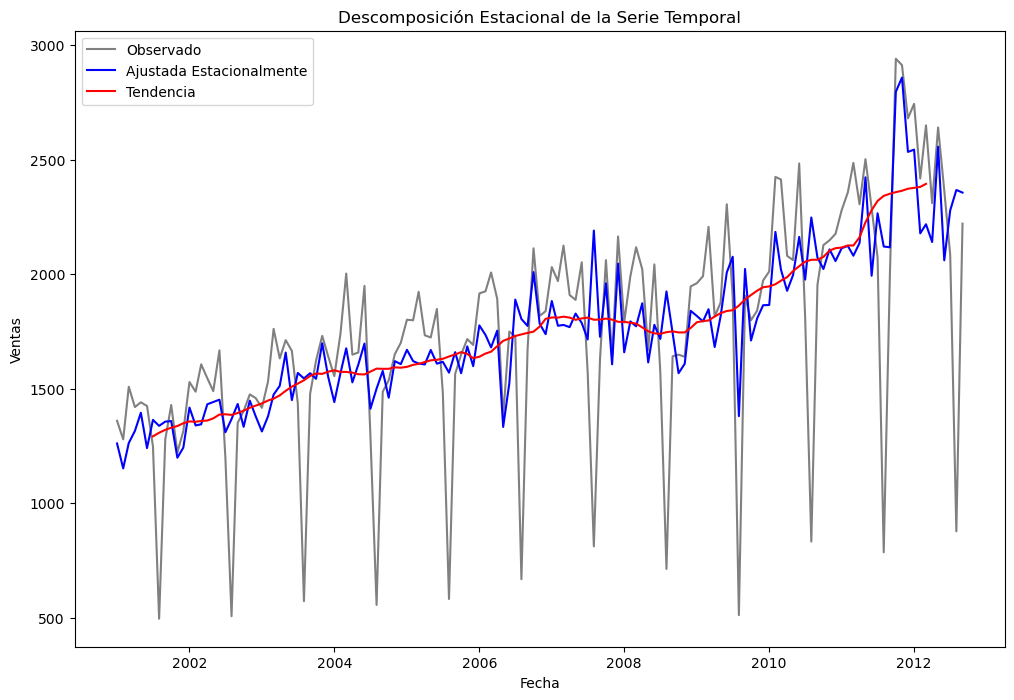

In [713]:

plt.figure(figsize=(12, 8))
plt.plot(result_papers_mul.observed, label='Observado', color='grey')

z = result_papers_mul.observed/result_papers_mul.seasonal #porque es esquema multiplicativo
plt.plot(z, label='Ajustada Estacionalmente', color='blue')
plt.plot(result_papers_mul.trend, label='Tendencia', color='red')

plt.legend()
plt.title('Descomposición Estacional de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

plt.show()

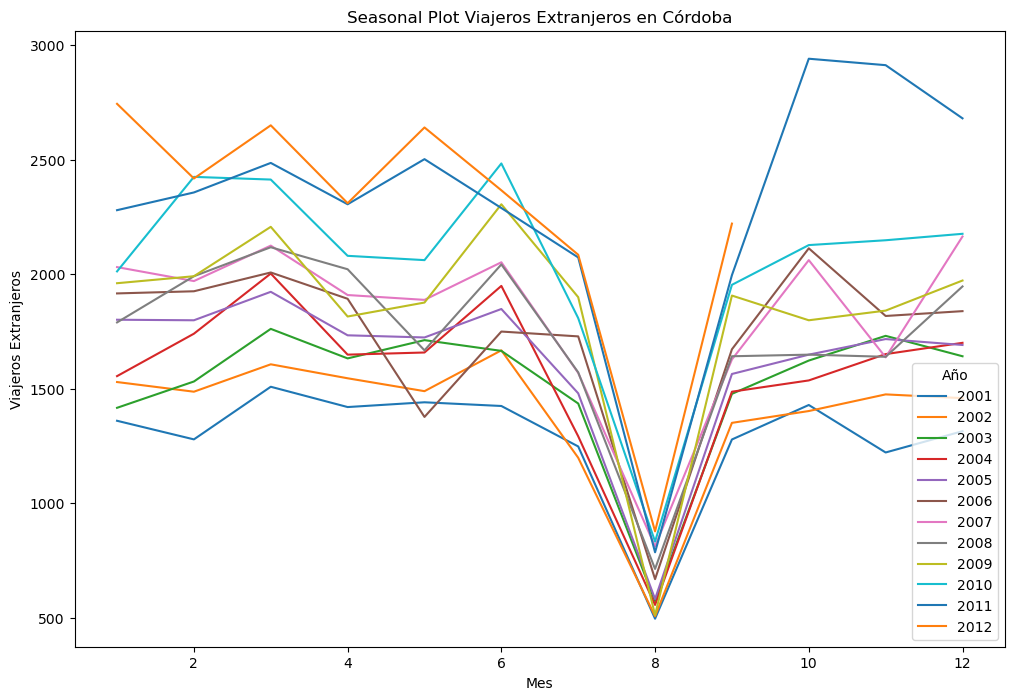

In [714]:
papers['Año'] = pd.to_datetime(papers.index, format='%Y-%m').year
plt.figure(figsize=(12, 8))
for Año, datos_año in papers.groupby('Año'):
    plt.plot(datos_año.index.month, datos_año['Sales'], label=str(Año))
# Añadir leyendas y título
plt.legend(title='Año')
plt.title('Seasonal Plot Viajeros Extranjeros en Córdoba')
plt.xlabel('Mes')
plt.ylabel('Viajeros Extranjeros')
# Mostrar el gráfico
plt.show()

In [715]:
#quitamos las 10 ultimas observaciones para poder realizar las predicciones con los metodos de alisado
data_TR = papers.iloc[:-9] 
data_TS = papers.iloc[-9:]
print(data_TR.tail())
print(data_TS)

               Sales   Año
Month                     
2011-08-01   785.575  2011
2011-09-01  1995.595  2011
2011-10-01  2940.630  2011
2011-11-01  2912.490  2011
2011-12-01  2680.335  2011
               Sales   Año
Month                     
2012-01-01  2743.650  2012
2012-02-01  2417.695  2012
2012-03-01  2649.850  2012
2012-04-01  2309.825  2012
2012-05-01  2640.470  2012
2012-06-01  2366.105  2012
2012-07-01  2084.705  2012
2012-08-01   877.030  2012
2012-09-01  2220.715  2012


# MODELOS DE SUAVIZADO

Con tendencia y estacionalidad multiplicativas

In [716]:
# Si el modelo no tiene tendencia ni estacionalidad: alisado simple.
# Si el modelo tiene tendencia y no tiene estacionalidad: alisado doble.
# Si el modelo tiene tendencia y estacionalidad: alisado Holt-Winters.

# Aplicar suavizado Holt-Winters.
modelo_holt_winters = sm.tsa.ExponentialSmoothing(data_TR['Sales'], trend='mul', 
                                                  seasonal='multiplicative', seasonal_periods=12).fit()
# Obtener predicciones para 1 año
predicciones_hw = modelo_holt_winters.forecast(steps=9)
# Mostrar la descripción del modelo
modelo_holt_winters.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


Dep. Variable:,Sales,No. Observations:,132
Model:,ExponentialSmoothing,SSE,2669357.306
Optimized:,True,AIC,1340.720
Trend:,Multiplicative,BIC,1386.845
Seasonal:,Multiplicative,AICC,1346.773
Seasonal Periods:,12,Date:,"Thu, 27 Feb 2025"
Box-Cox:,False,Time:,12:50:23
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2525000,alpha,True
smoothing_trend,0.0001000,beta,True


In [717]:
predicciones_hw

2012-01-01    2726.078615
2012-02-01    2855.426083
2012-03-01    3085.251024
2012-04-01    2793.581271
2012-05-01    2751.984838
2012-06-01    3021.153320
2012-07-01    2444.142745
2012-08-01    1038.875143
2012-09-01    2582.701441
Freq: MS, dtype: float64

In [718]:
modelo_holt_winters.params

{'smoothing_level': 0.25249998561335374,
 'smoothing_trend': 0.0001000034597780524,
 'smoothing_seasonal': 0.029900004716412007,
 'damping_trend': nan,
 'initial_level': 1295.0013774402837,
 'initial_trend': 1.0091693881531008,
 'initial_seasons': array([1.11454276, 1.1582869 , 1.23816355, 1.11099968, 1.08997862,
        1.17900095, 0.94601535, 0.40507502, 0.98165186, 1.10771925,
        1.07453048, 1.10313888]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

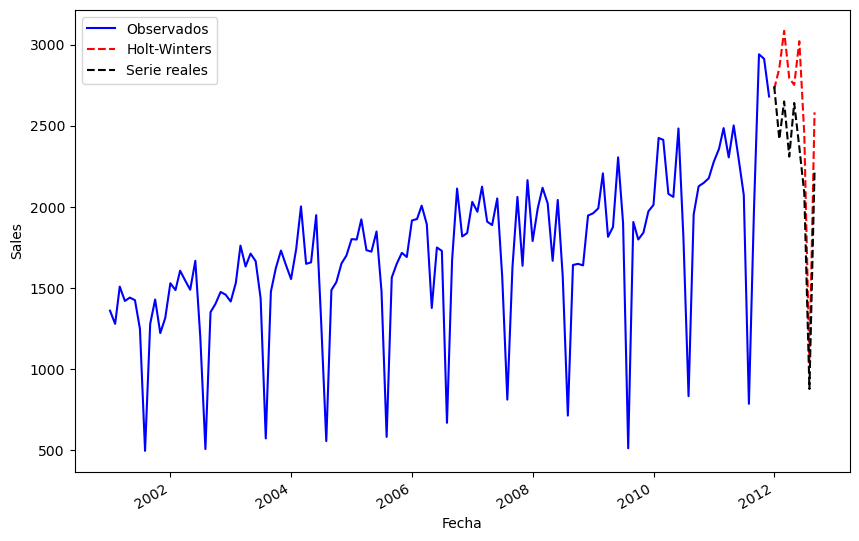

In [719]:
plt.figure(figsize=(10, 6))
plt.plot(data_TR.index, data_TR['Sales'], label='Observados', linestyle='-', color='blue')
plt.plot(predicciones_hw.index, predicciones_hw, label='Holt-Winters', linestyle='--',color='red')
plt.plot(data_TS.index, data_TS['Sales'], label='Serie reales', linestyle='--',color='black')
plt.xlabel('Fecha')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()

In [720]:
mse = mean_squared_error(data_TS['Sales'], predicciones_hw)
print(f'Mean Squared Error (MSE): {mse}')
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')
# Mean Absolute Error (MAE)
mae = mean_absolute_error(data_TS['Sales'], predicciones_hw)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Squared Error (MSE): 149273.20253889236
Root Mean Squared Error (RMSE): 386.3589037914001
Mean Absolute Error (MAE): 336.0324722056814


Modelo con tendencia y estacionalidad aditivas

In [721]:

# Aplicar suavizado Holt-Winters.
modelo_holt_winters_add = sm.tsa.ExponentialSmoothing(data_TR['Sales'], trend='add', 
                                                  seasonal='additive', seasonal_periods=12).fit()
# Obtener predicciones para 1 año
predicciones_hw_add = modelo_holt_winters_add.forecast(steps=9)
# Mostrar la descripción del modelo
modelo_holt_winters_add.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Dep. Variable:,Sales,No. Observations:,132
Model:,ExponentialSmoothing,SSE,3267847.099
Optimized:,True,AIC,1367.423
Trend:,Additive,BIC,1413.548
Seasonal:,Additive,AICC,1373.476
Seasonal Periods:,12,Date:,"Thu, 27 Feb 2025"
Box-Cox:,False,Time:,12:50:24
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.1666962,alpha,True
smoothing_trend,0.0001918,beta,True


In [722]:
predicciones_hw_add

2012-01-01    2578.450222
2012-02-01    2689.952979
2012-03-01    2808.790522
2012-04-01    2582.595087
2012-05-01    2556.786709
2012-06-01    2740.367085
2012-07-01    2345.049318
2012-08-01    1323.442249
2012-09-01    2418.691813
Freq: MS, dtype: float64

In [723]:
modelo_holt_winters_add.params

{'smoothing_level': 0.16669616144361057,
 'smoothing_trend': 0.00019178341892844432,
 'smoothing_seasonal': 0.20161007931390318,
 'damping_trend': nan,
 'initial_level': 1221.2278260253654,
 'initial_trend': 9.303930337979324,
 'initial_seasons': array([ 109.6742599 ,  127.1494357 ,  285.97014938,  117.85695408,
          83.48495129,  207.68147862, -153.31474795, -970.99980807,
         -59.59709458,   82.82587184,   33.26287261,   62.81030285]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

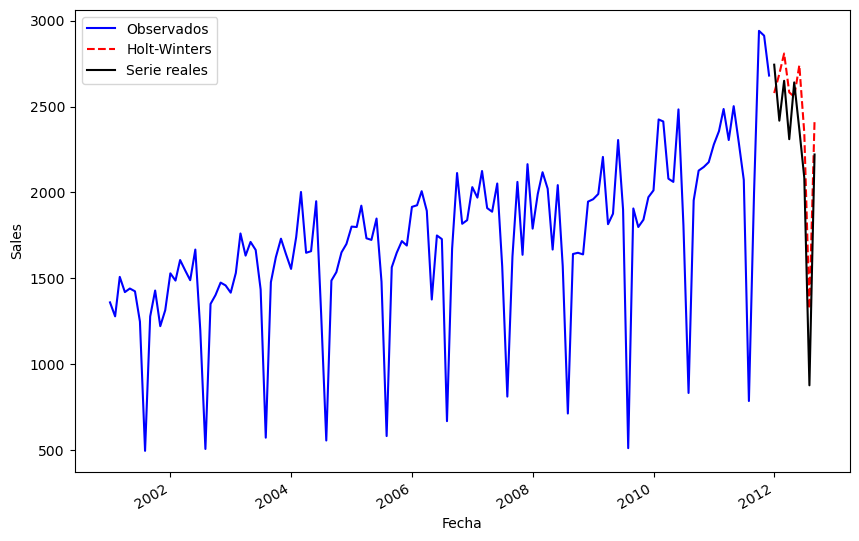

In [724]:
plt.figure(figsize=(10, 6))
plt.plot(data_TR.index, data_TR['Sales'], label='Observados', linestyle='-', color='blue')

plt.plot(predicciones_hw_add.index, predicciones_hw_add, label='Holt-Winters', linestyle='--',color='red')
plt.plot(data_TS.index, data_TS['Sales'], label='Serie reales', linestyle='-',color='black')
plt.xlabel('Fecha')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()

In [725]:
mse = mean_squared_error(data_TS['Sales'], predicciones_hw_add)
print(f'Mean Squared Error (MSE): {mse}')
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')
# Mean Absolute Error (MAE)
mae = mean_absolute_error(data_TS['Sales'], predicciones_hw_add)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Squared Error (MSE): 72712.65144786691
Root Mean Squared Error (RMSE): 269.65283504511297
Mean Absolute Error (MAE): 247.98301350569136


HEMOS PROBADO LOS 2 ESQUEMAS ADITIVO Y MULTIPLICATIVO Y PARECE QUE ADITIVO SE AJUSTA MEJOR. AHORA VEREMOS EL MODELO HW CON TENDENCIA Y ESTACIONALIDAD ADITIVAS PERO HABIENDO TRANSFORMADO LA SERIE PREVIAMENTE 

In [726]:
papers_log = np.log(data_TR['Sales'])

papers_log_diff = papers_log.diff().dropna()

modelo_hw_diff = sm.tsa.ExponentialSmoothing(papers_log_diff,
                                      trend='add',
                                      seasonal='add',
                                      seasonal_periods=12).fit()

pred_diff = modelo_hw_diff.forecast(steps=9)


c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [727]:
last_log_value = papers_log.iloc[-1]  

pred_log = last_log_value + pred_diff.cumsum()

pred_final = np.exp(pred_log)

print(pred_final)

2012-01-01    2751.045387
2012-02-01    2865.622950
2012-03-01    3125.018671
2012-04-01    2834.738067
2012-05-01    2744.040465
2012-06-01    3051.208086
2012-07-01    2461.008139
2012-08-01     999.908400
2012-09-01    2581.136390
Freq: MS, dtype: float64


In [728]:
mse = mean_squared_error(data_TS['Sales'], pred_diff)
print(f'Mean Squared Error (MSE): {mse}')
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')
# Mean Absolute Error (MAE)
mae = mean_absolute_error(data_TS['Sales'], pred_diff)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Squared Error (MSE): 5371637.098093945
Root Mean Squared Error (RMSE): 2317.6792483201693
Mean Absolute Error (MAE): 2256.6758568914884


COMPARAMOS EN UNA GRAFICA LOS MODELOS HW SIN Y CON TRANSFORMACION PREVIA DE LA SERIE

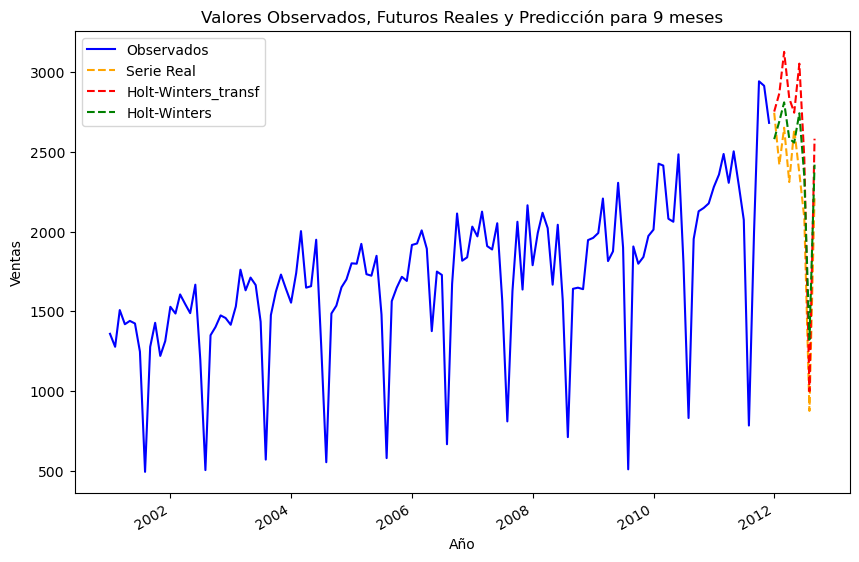

In [729]:
plt.figure(figsize=(10, 6))
plt.plot(data_TR.index, data_TR['Sales'], label='Observados', linestyle='-', color='blue')
plt.plot(data_TS.index, data_TS['Sales'], label='Serie Real', linestyle='--', color='orange')
plt.plot(pred_final.index, pred_final, label='Holt-Winters_transf', linestyle='--',color='red')
plt.plot(predicciones_hw_add.index, predicciones_hw_add, label='Holt-Winters', linestyle='--',color='green')
predicciones_hw
plt.xlabel('Año')
plt.ylabel('Ventas')
plt.title('Valores Observados, Futuros Reales y Predicción para 9 meses')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()

# ACF y PACF

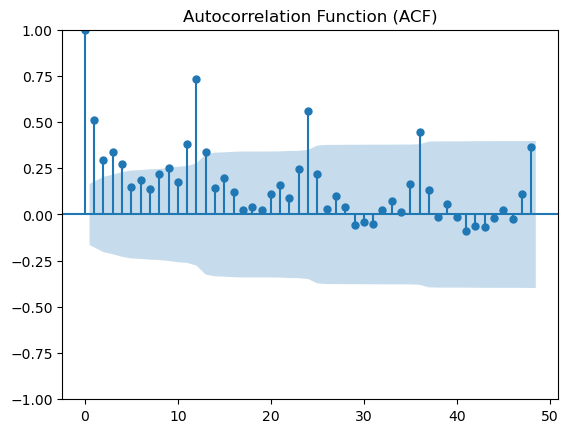

In [730]:

# Plot ACF
plot_acf(papers['Sales'], lags=48, alpha = 0.05)
plt.title('Autocorrelation Function (ACF)')
plt.show()

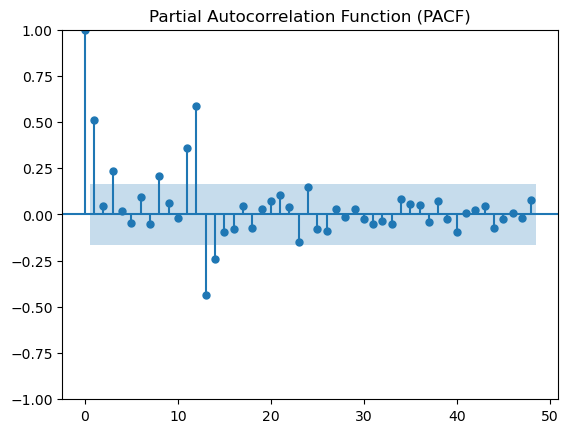

In [731]:
# Plot PACF
plot_pacf(papers['Sales'], lags=48, alpha = 0.05)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

# SERIE DIFERENCIADA 1 VEZ

Text(0.5, 1.0, 'ACF serie diferenciada')

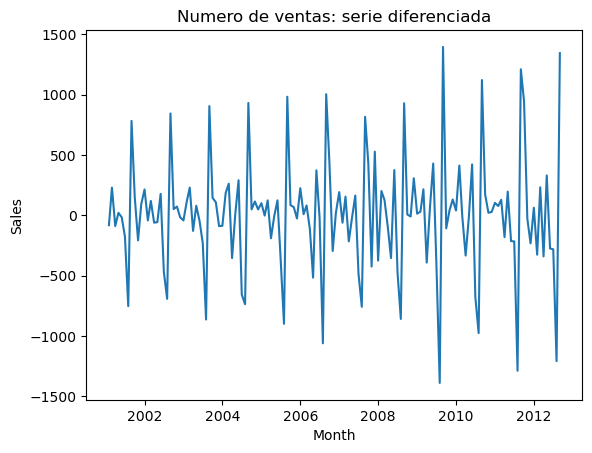

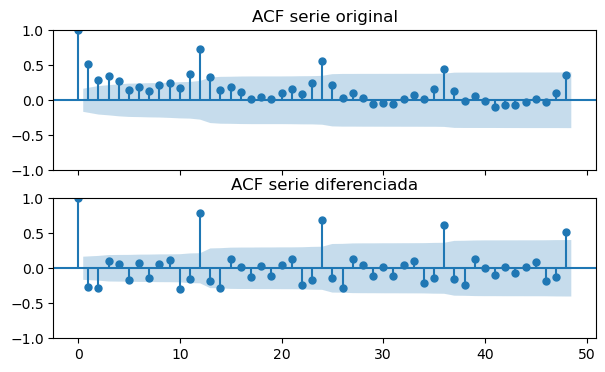

In [732]:
papers_diff_1 = papers.diff(1).dropna()
sns.lineplot(papers_diff_1['Sales'])
plt.title('Numero de ventas: serie diferenciada')

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(7,4), sharex=True)
plot_acf(papers['Sales'], ax=axs[0], lags=48, alpha=0.05)
axs[0].set_title('ACF serie original')
plot_acf(papers_diff_1['Sales'], ax=axs[1], lags=48, alpha=0.05)
axs[1].set_title('ACF serie diferenciada')


HACEMOS LOS CONTRASTES DE HIPOTESIS PARA VER SI LA SERIE DIFERENCIADA ES ESTACIONARIA O NO

In [733]:
#vamos a hacer el test para ver si es o no estacionaria
adf_stat, adf_p = adfuller(papers["Sales"])[:2]
kpss_stat, kpss_p = kpss(papers["Sales"])[:2]

print('Test estacionariedad serie original')
print(f'ADF Statistic: {adf_stat}, p-value: {adf_p}')
print(f'KPSS Statistic: {kpss_stat}, p-value: {kpss_p}')

# Para la serie diferenciada
adf_stat_diff, adf_p_diff = adfuller(papers_diff_1['Sales'])[:2]
kpss_stat_diff, kpss_p_diff = kpss(papers_diff_1['Sales'])[:2]

print('\nTest estacionariedad serie diferenciada de orden 1')
print(f'ADF Statistic: {adf_stat_diff}, p-value: {adf_p_diff}')
print(f'KPSS Statistic: {kpss_stat_diff}, p-value: {kpss_p_diff}')


Test estacionariedad serie original
ADF Statistic: 1.3378520891779668, p-value: 0.9968126868076331
KPSS Statistic: 1.4179733723892451, p-value: 0.01

Test estacionariedad serie diferenciada de orden 1
ADF Statistic: -5.241717332851631, p-value: 7.222055509337766e-06
KPSS Statistic: 0.1297353189746937, p-value: 0.1


C:\Users\maria\AppData\Local\Temp\ipykernel_17432\2176366846.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p = kpss(papers["Sales"])[:2]
C:\Users\maria\AppData\Local\Temp\ipykernel_17432\2176366846.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat_diff, kpss_p_diff = kpss(papers_diff_1['Sales'])[:2]


Como 7.22exp-6 < 0.05 ---> La diferenciada es estacionaria -----> d = 1 

Text(0.5, 1.0, 'PACF (order=1)')

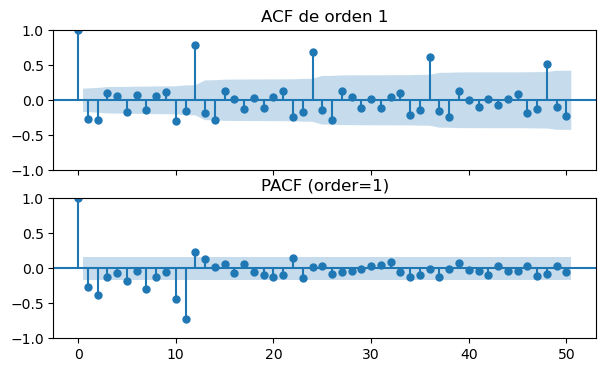

In [734]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(7, 4), sharex=True)
plot_acf(papers_diff_1['Sales'], ax=axs[0], lags=50, alpha=0.05)
axs[0].set_title('ACF de orden 1')
plot_pacf(papers_diff_1['Sales'], ax=axs[1], lags=50, alpha=0.05)
axs[1].set_title('PACF (order=1)')

vemos los graficos y p = 2 y q = 2

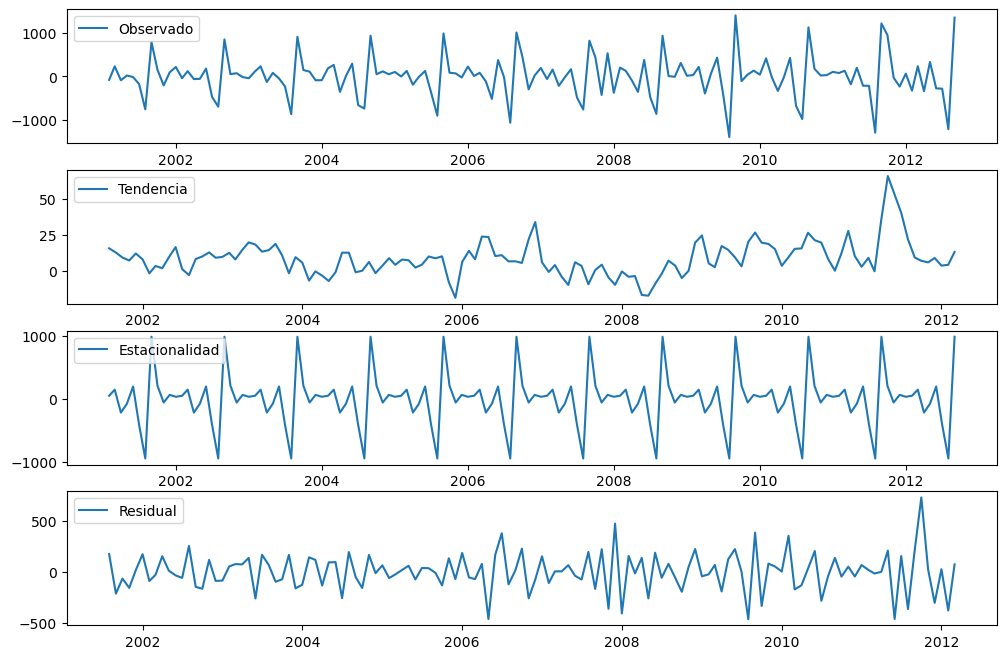

In [735]:
papers_diff_1_decomp = seasonal_decompose(papers_diff_1['Sales'], model='additive')


plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(papers_diff_1_decomp.observed, label='Observado')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(papers_diff_1_decomp.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
#result.seasonal nos dara las componentes de estacionalidad
plt.plot(papers_diff_1_decomp.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(papers_diff_1_decomp.resid, label='Residual')
plt.legend(loc='upper left')

# SERIE DIFERENCIADA 12 VECES

p-valor adfuller: 2.4181531067799636e-07
p-valor kpss: 0.08767119036931545


Text(0.5, 1.0, 'PACF serie diferenciada 12')

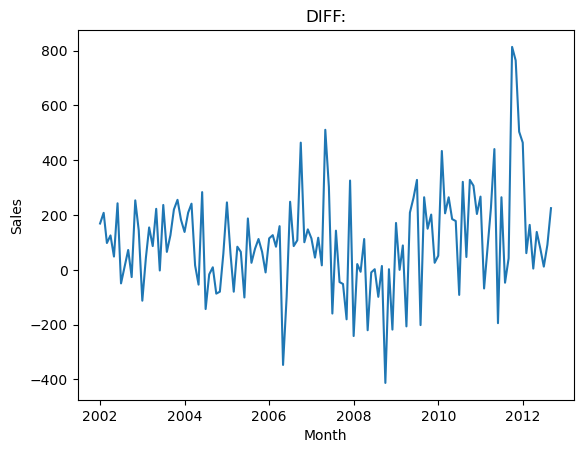

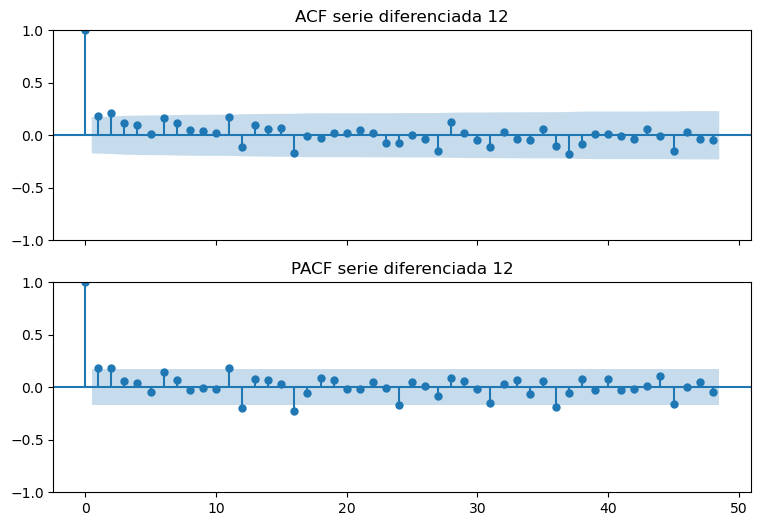

In [736]:

datos_diff_12 = papers['Sales'].diff(12).dropna() #Quito la tendencia
sns.lineplot(datos_diff_12)
plt.title('DIFF:') #diff = 12 porque hay 12 periodos sigo con d = 1

print(f'p-valor adfuller: {adfuller(datos_diff_12)[1]}') # < 0.05 rechazo hipotesis nula, es estacionaria la diferenciada
print(f'p-valor kpss: {kpss(datos_diff_12)[1]}') # > 0.05 acepto la hipotesis nula, es estacionaria

fig, axs = plt.subplots(nrows=2, ncols=1,
figsize=(9, 6), sharex=True)
plot_acf(datos_diff_12, ax=axs[0],
lags=48, alpha=0.05)
axs[0].set_title('ACF serie diferenciada 12') # q = 0 (o 2)
plot_pacf(datos_diff_12, ax=axs[1],
lags=48, alpha=0.05)
axs[1].set_title('PACF serie diferenciada 12') 


Como 0.012 <0-5 ----> es estacionaria la serie diferenciada 12 y por tanto D = 1.
Ademas viendo los graficos, vemos como Q = 0,1 o 2 y P = 0,1 o 2.

# MODELOS ARIMA

In [737]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo0 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (0, 1, 2, 12))
modelo_res0 = modelo0.fit(disp=0)
warnings.filterwarnings("default")
modelo_res0.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(0, 1, 2, 12)   Log Likelihood                -781.288
Date:                            Thu, 27 Feb 2025   AIC                           1576.576
Time:                                    12:50:28   BIC                           1596.030
Sample:                                01-01-2001   HQIC                          1584.476
                                     - 12-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9157      0.151     -6.052      0.000      -1.212      -0.619
ar.L2          0.0421      0.119      0.352      0.725      -0.192       0.276
ma.L1          0.1740      2.248      0.077      0.938      -4.233       4.581
ma.L2         -0.8251      1.855     -0.445      0.657      -4.462       2.812
ma.S.L12      -0.5130      0.168     -3.054      0.002      -0.842      -0.184
ma.S.L24      -0.1515      0.131     -1.155      0.248      -0.409       0.105
sigma2       2.73e+04   5.94e+04      0.460      0.646   -8.91e+04    1.44e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                63.37
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               4.10   Skew:                             0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

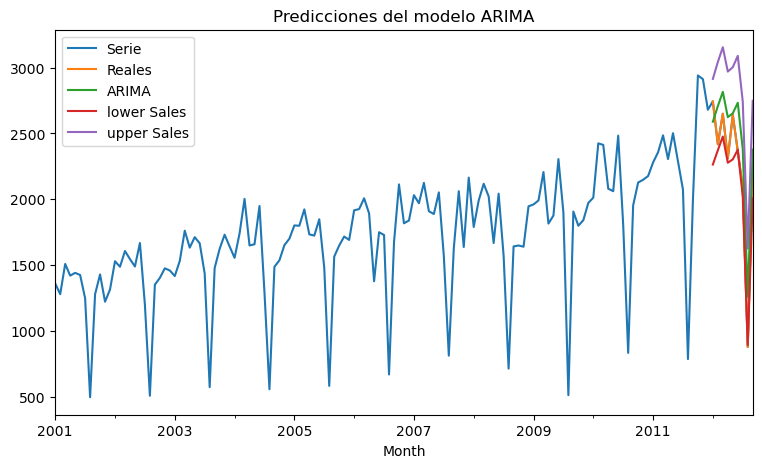

In [738]:
# Predicción
predicciones_statsmodels_0 = modelo_res0.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res0.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_0.name = 'predicciones_statsmodels'
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_0.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()


In [739]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo1 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (1, 1, 2, 12))
modelo_res1 = modelo1.fit(disp=0)
warnings.filterwarnings("default")
modelo_res1.summary()


c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(1, 1, 2, 12)   Log Likelihood                -781.456
Date:                            Thu, 27 Feb 2025   AIC                           1578.911
Time:                                    12:50:31   BIC                           1601.144
Sample:                                01-01-2001   HQIC                          1587.940
                                     - 12-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9637      0.169     -5.710      0.000      -1.294      -0.633
ar.L2         -0.0017      0.132     -0.013      0.989      -0.260       0.257
ma.L1          0.2041      0.533      0.383      0.702      -0.840       1.249
ma.L2         -0.7913      0.426     -1.858      0.063      -1.626       0.043
ar.S.L12       0.1408      1.156      0.122      0.903      -2.124       2.406
ma.S.L12      -0.6583      1.192     -0.552      0.581      -2.994       1.678
ma.S.L24      -0.0508      0.665     -0.076      0.939      -1.355       1.253
sigma2      2.896e+04   1.29e+04      2.240      0.025    3618.593    5.43e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                70.51
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               4.14   Skew:                             0.78
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

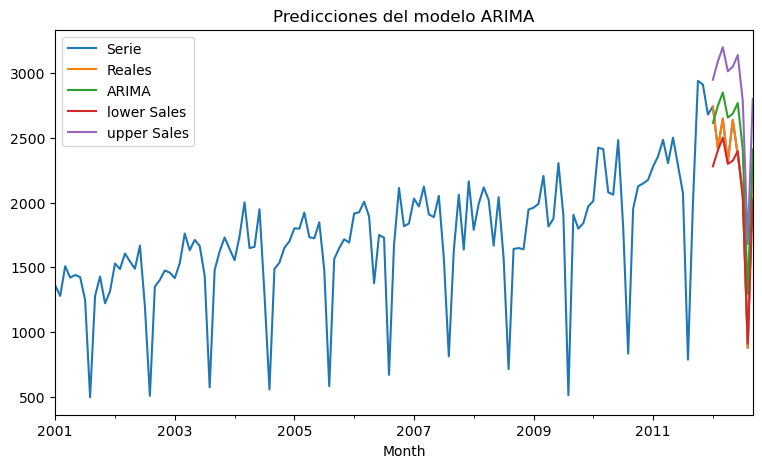

In [740]:
# Predicción
predicciones_statsmodels_1 = modelo_res1.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res1.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_1.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_1.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()


In [741]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo2 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (2, 1, 2, 12))
modelo_res2 = modelo2.fit(disp=0)
warnings.filterwarnings("default")
modelo_res2.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(2, 1, 2, 12)   Log Likelihood                -780.568
Date:                            Thu, 27 Feb 2025   AIC                           1579.136
Time:                                    12:50:34   BIC                           1604.148
Sample:                                01-01-2001   HQIC                          1589.292
                                     - 12-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8901      0.150     -5.920      0.000      -1.185      -0.595
ar.L2          0.0619      0.119      0.522      0.601      -0.170       0.294
ma.L1          0.1619      0.443      0.365      0.715      -0.706       1.030
ma.L2         -0.8324      0.382     -2.180      0.029      -1.581      -0.084
ar.S.L12      -0.6841      0.299     -2.285      0.022      -1.271      -0.097
ar.S.L24       0.3151      0.264      1.195      0.232      -0.202       0.832
ma.S.L12       0.2120      0.556      0.382      0.703      -0.877       1.301
ma.S.L24      -0.7723      0.364     -2.121      0.034      -1.486      -0.059
sigma2       2.59e+04   3.72e-05   6.96e+08      0.000    2.59e+04    2.59e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                59.95
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               4.13   Skew:                             0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 5.65e+25. Standard errors may be unstable.
"""

Me quedo con el segundo que tiene menor AIC y BIC

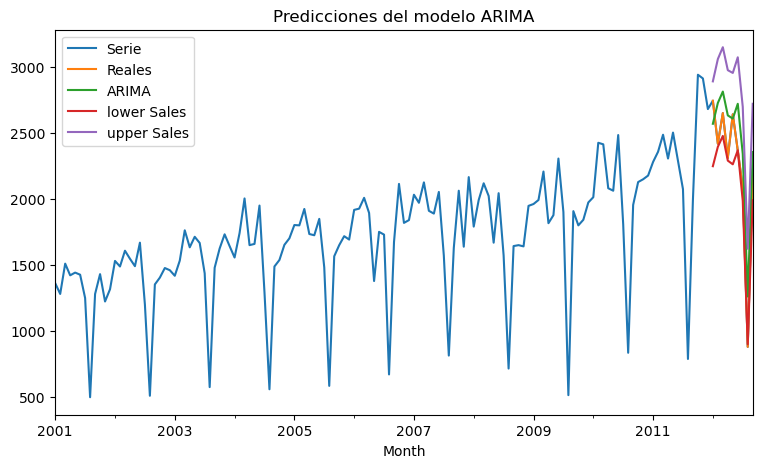

In [742]:
# Predicción
predicciones_statsmodels_2 = modelo_res2.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res2.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_2.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_2.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()


In [743]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo3 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (2, 1, 0, 12))
modelo_res3 = modelo3.fit(disp=0)
warnings.filterwarnings("default")
modelo_res3.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(2, 1, [], 12)   Log Likelihood                -784.246
Date:                             Thu, 27 Feb 2025   AIC                           1582.491
Time:                                     12:50:36   BIC                           1601.945
Sample:                                 01-01-2001   HQIC                          1590.391
                                      - 12-01-2011                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9575      0.133     -7.187      0.000      -1.219      -0.696
ar.L2         -0.0042      0.111     -0.038      0.970      -0.222       0.214
ma.L1          0.1815      0.634      0.286      0.775      -1.061       1.424
ma.L2         -0.8162      0.530     -1.540      0.124      -1.855       0.222
ar.S.L12      -0.3452      0.134     -2.570      0.010      -0.609      -0.082
ar.S.L24      -0.1605      0.107     -1.499      0.134      -0.370       0.049
sigma2      2.998e+04   1.77e+04      1.689      0.091   -4804.846    6.48e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                51.34
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               4.21   Skew:                             0.70
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

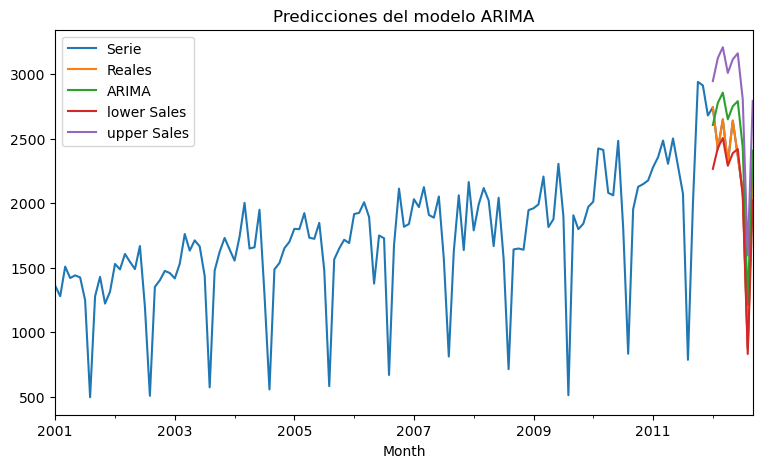

In [744]:
# Predicción
predicciones_statsmodels_3 = modelo_res3.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res3.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_3.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_3.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()

In [745]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo4 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (1, 1, 1, 12))
modelo_res4 = modelo4.fit(disp=0)
warnings.filterwarnings("default")
modelo_res4.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -781.307
Date:                              Thu, 27 Feb 2025   AIC                           1576.614
Time:                                      12:50:38   BIC                           1596.068
Sample:                                  01-01-2001   HQIC                          1584.514
                                       - 12-01-2011                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9163      0.154     -5.969      0.000      -1.217      -0.615
ar.L2          0.0404      0.119      0.340      0.734      -0.193       0.274
ma.L1          0.1705      0.956      0.178      0.858      -1.703       2.044
ma.L2         -0.8269      0.797     -1.038      0.299      -2.388       0.735
ar.S.L12       0.2710      0.261      1.037      0.300      -0.241       0.783
ma.S.L12      -0.7607      0.208     -3.660      0.000      -1.168      -0.353
sigma2      2.812e+04   2.48e+04      1.134      0.257   -2.05e+04    7.67e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                58.84
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               4.10   Skew:                             0.70
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

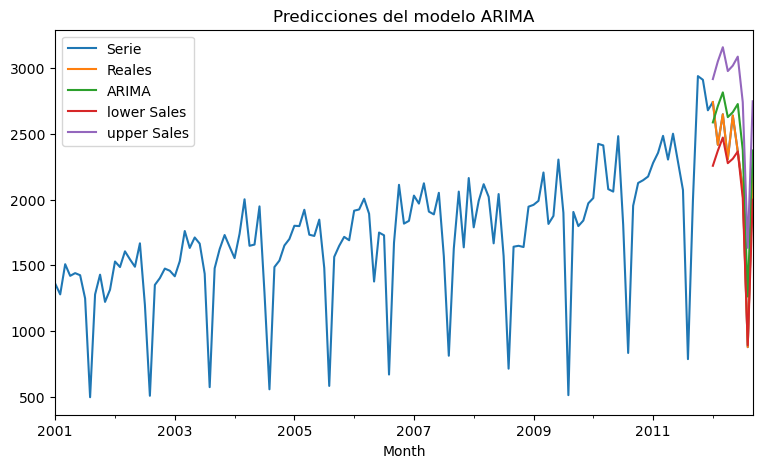

In [746]:
# Predicción
predicciones_statsmodels_4 = modelo_res4.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res4.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_4.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_4.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()

In [747]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo5 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (0, 1, 1, 12))
modelo_res5 = modelo5.fit(disp=0)
warnings.filterwarnings("default")
modelo_res5.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -782.455
Date:                              Thu, 27 Feb 2025   AIC                           1576.911
Time:                                      12:50:39   BIC                           1593.586
Sample:                                  01-01-2001   HQIC                          1583.682
                                       - 12-01-2011                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9109      0.152     -5.980      0.000      -1.210      -0.612
ar.L2          0.0521      0.125      0.415      0.678      -0.194       0.298
ma.L1          0.1790      1.918      0.093      0.926      -3.581       3.939
ma.L2         -0.8201      1.581     -0.519      0.604      -3.918       2.278
ma.S.L12      -0.5911      0.130     -4.563      0.000      -0.845      -0.337
sigma2      2.816e+04    5.2e+04      0.541      0.588   -7.38e+04     1.3e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                74.72
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               4.35   Skew:                             0.81
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

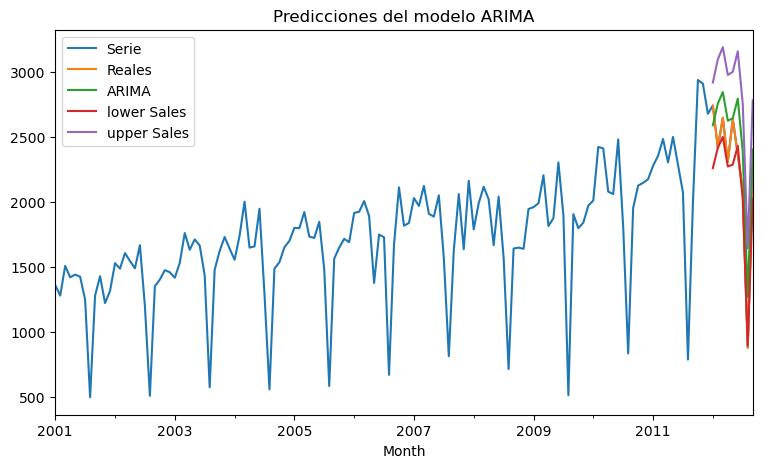

In [748]:
# Predicción
predicciones_statsmodels_5 = modelo_res5.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res5.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_5.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_5.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()

In [749]:
#MODELO SARIMA

warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo6 = SARIMAX(endog = data_TR['Sales'], order = (2, 1, 2), seasonal_order = (0, 1, 0, 12))
modelo_res6 = modelo6.fit(disp=0)
warnings.filterwarnings("default")
modelo_res6.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               Sales   No. Observations:                  132
Model:             SARIMAX(2, 1, 2)x(0, 1, [], 12)   Log Likelihood                -790.033
Date:                             Thu, 27 Feb 2025   AIC                           1590.066
Time:                                     12:50:40   BIC                           1603.962
Sample:                                 01-01-2001   HQIC                          1595.709
                                      - 12-01-2011                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6168      0.982     -0.628      0.530      -2.542       1.309
ar.L2          0.0425      0.152      0.279      0.780      -0.256       0.341
ma.L1         -0.2431      0.972     -0.250      0.803      -2.148       1.662
ma.L2         -0.5169      0.765     -0.675      0.499      -2.017       0.983
sigma2      3.383e+04   3622.118      9.341      0.000    2.67e+04    4.09e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                16.17
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               3.67   Skew:                             0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

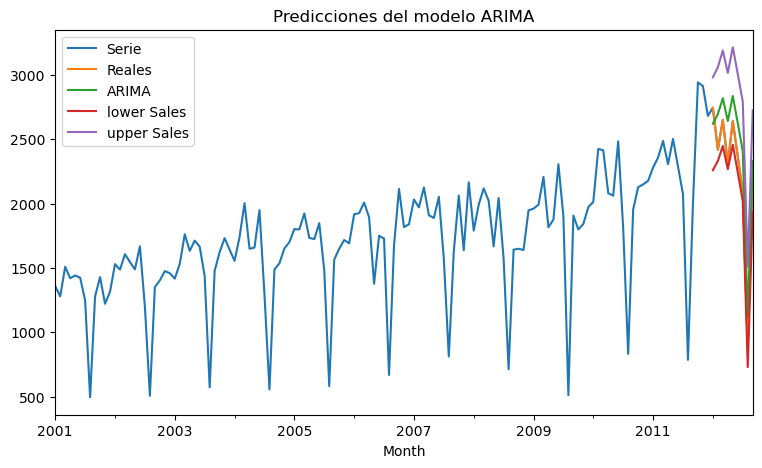

In [750]:
# Predicción
predicciones_statsmodels_6 = modelo_res6.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res6.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_6.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_6.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()

Comparamos los 7 modelos anteriores

In [760]:
modelos_sarima = [predicciones_statsmodels_0, predicciones_statsmodels_1, predicciones_statsmodels_2, predicciones_statsmodels_3,\
                  predicciones_statsmodels_4, predicciones_statsmodels_5, predicciones_statsmodels_6]
mse_min = math.inf
for i,pred in enumerate(modelos_sarima):
    mse = mean_squared_error(data_TS['Sales'], pred)
    print(f'Mean Squared Error (MSE) modelo {i}: {mse}')
    rmse = np.sqrt(mse)
    print(f'Root Mean Squared Error (RMSE) modelo {i}: {rmse}')
    mae = mean_absolute_error(data_TS['Sales'], pred)
    print(f'Mean Absolute Error (MAE)modelo {i}: {mae}\n')
    if mse < mse_min:
        i_best = i


print(f"El mejor modelo es el modelo {i_best}")

    

Mean Squared Error (MSE) modelo 0: 69794.58696949437
Root Mean Squared Error (RMSE) modelo 0: 264.18665176252637
Mean Absolute Error (MAE)modelo 0: 237.8663375626457

Mean Squared Error (MSE) modelo 1: 85488.31107523855
Root Mean Squared Error (RMSE) modelo 1: 292.3838420214745
Mean Absolute Error (MAE)modelo 1: 265.903977489844

Mean Squared Error (MSE) modelo 2: 68097.24554082597
Root Mean Squared Error (RMSE) modelo 2: 260.9544894053865
Mean Absolute Error (MAE)modelo 2: 236.5403514305252

Mean Squared Error (MSE) modelo 3: 85176.69049386692
Root Mean Squared Error (RMSE) modelo 3: 291.8504591291008
Mean Absolute Error (MAE)modelo 3: 272.056011310699

Mean Squared Error (MSE) modelo 4: 70009.2529752006
Root Mean Squared Error (RMSE) modelo 4: 264.5926170081104
Mean Absolute Error (MAE)modelo 4: 239.47744234567816

Mean Squared Error (MSE) modelo 5: 82794.48132414249
Root Mean Squared Error (RMSE) modelo 5: 287.74030187678346
Mean Absolute Error (MAE)modelo 5: 258.32091747393594

Mea

MODELO AUTOARIMA

In [765]:
modelo = auto_arima(
            y                 = papers['Sales'],
            start_p           = 0,
            start_q           = 0,
            max_p             = 3,
            max_q             = 3,
            seasonal          = True,
            test              = 'adf',
            m                 = 12, # periodicidad de la estacionalidad
            d                 = None, # El algoritmo determina 'd'
            D                 = None, # El algoritmo determina 'D'
            trace             = True,
            error_action      = 'ignore',
            suppress_warnings = True,
            stepwise          = True)

c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\m

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.90 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1718.829, Time=0.06 sec


c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1713.899, Time=0.70 sec


c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(2,0,0)(0,1,2)[12] intercept   : AIC=1702.770, Time=0.80 sec


c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=1705.644, Time=1.28 sec


c:\Users\maria\Anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(0,1,2)[12]             : AIC=1705.196, Time=0.82 sec

Best model:  ARIMA(1,0,1)(0,1,2)[12] intercept
Total fit time: 16.781 seconds


In [770]:
warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
modelo_auto = SARIMAX(endog = data_TR['Sales'], order = (1, 0, 1), seasonal_order = (0, 1, 2, 12))
modelo_res_auto = modelo_auto.fit(disp=0)
warnings.filterwarnings("default")
modelo_res_auto.summary()

c:\Users\maria\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                   Sales   No. Observations:                  132
Model:             SARIMAX(1, 0, 1)x(0, 1, [1, 2], 12)   Log Likelihood                -787.708
Date:                                 Thu, 27 Feb 2025   AIC                           1585.416
Time:                                         13:25:49   BIC                           1599.353
Sample:                                     01-01-2001   HQIC                          1591.076
                                          - 12-01-2011                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9955      0.008    129.635      0.000       0.980       1.011
ma.L1         -0.8106      0.055    -14.650      0.000      -0.919      -0.702
ma.S.L12      -0.5367      0.168     -3.201      0.001      -0.865      -0.208
ma.S.L24      -0.1716      0.139     -1.239      0.215      -0.443       0.100
sigma2      2.761e+04   2386.981     11.566      0.000    2.29e+04    3.23e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):                87.77
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               4.43   Skew:                             0.85
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

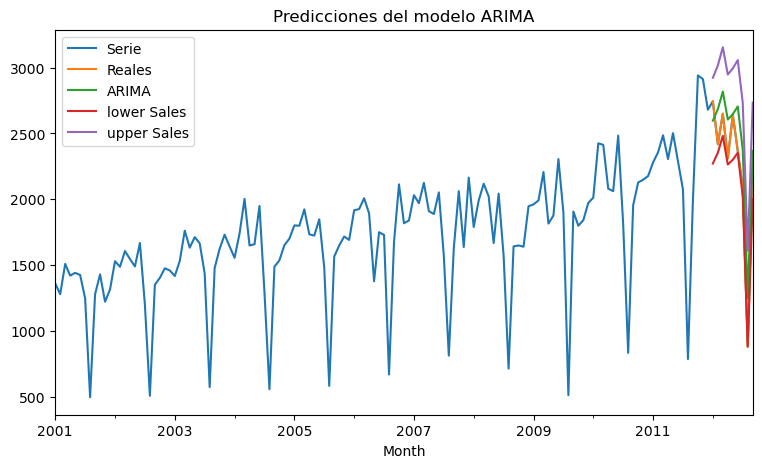

In [771]:
# Predicción
predicciones_statsmodels_auto = modelo_res_auto.get_forecast(steps=9).predicted_mean
intervalos_confianza  = modelo_res_auto.get_forecast(steps=9).conf_int(alpha=0.05)

pred_lower = intervalos_confianza.iloc[:, 0]
pred_upper = intervalos_confianza.iloc[:, 1]
pred_lower.name = "intervalo_infer"
pred_upper.name = "intervalo_super"
predicciones_statsmodels_auto.name = 'predicciones_statsmodels'
# se comprueba lo predicho con los valores reales
datos_futuro = papers.loc['2012-01-01':'2012-09-01']
datos_futuro = datos_futuro['Sales']

# Plot predictions
fig, ax = plt.subplots(figsize=(9, 5))
papers['Sales'].plot(ax=ax, label='Serie')
datos_futuro.plot(ax=ax, label='Reales')
predicciones_statsmodels_auto.plot(ax=ax, label='ARIMA')
intervalos_confianza.plot(ax=ax, label='Intervalos')
ax.set_title('Predicciones del modelo ARIMA')
ax.legend()


COMPARAMOS LOS ERRORES OBTENIDOS POR CADA UNO DE LOS 3 MODELOS ARIMA

In [772]:

mse = mean_squared_error(data_TS['Sales'], predicciones_statsmodels_auto)
print(f'Mean Squared Error (MSE): {mse}')
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')
# Mean Absolute Error (MAE)
mae = mean_absolute_error(data_TS['Sales'], predicciones_statsmodels_auto)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Squared Error (MSE): 62897.27593490462
Root Mean Squared Error (RMSE): 250.79329324147528
Mean Absolute Error (MAE): 225.54020254504286
